# Zadanie 1

Na wykładzie w Części 3 omówiliśmy programowanie genetyczne (GP, przejrzyj teraz pdf wykładowy). DEAP potrafi optymalizować GP (przykłady kodu są też w pdf wykładowym). Stwórz mapowanie przestrzeni GP do jednej, wybranej reprezentacji genetycznej we Framsticks. Po stronie GP potrzebne będą własne węzły funkcyjne i terminale oraz funkcja oceny drzewa, która musi wyprodukować z niego genotyp w docelowej reprezentacji Framsticks.

Mamy do czynienia z problemem, w którym algorytmy optymalizacji (np. ewolucyjny) z trudem odkrywają dobre rozwiązania, nie docierając do optimum globalnego. Pytanie: czy optymalizacja w tworzonej w tym zadaniu przestrzeni GP (transformującej każdy genotyp GP do jakiegoś genotypu w natywnej reprezentacji Framsticks) jest w stanie uzyskiwać lepsze wyniki, niż analogiczna optymalizacja z natywną reprezentacją i jej operatorami we Framsticks? Pamiętaj, że reprezentacja GP przy takim podejściu nie jest w stanie wytworzyć niczego, czego nie da się wytworzyć w natywnej reprezentacji (do której GP jest transformowane). Uzasadnij swoją odpowiedź. Możesz uogólnić to pytanie do dwóch reprezentacji A i B, jednej tłumaczonej do drugiej, zupełnie abstrahując od Framsticks i GP – odpowiedź na takie uogólnione pytanie oraz jej uzasadnienie będą takie same.

Optymalizacja algorytmem ewolucyjnym w przestrzeni GP nie może dawać lepszych wyników, ponieważ każde drzewo GP jest w końcu tłumaczone na genotyp w natywnej reprezentacji Framsticks, a GP nie może wygenerować żadnego rozwiązania, którego nie dałoby się uzyskać bezpośrednio w natywnej przestrzeni. W związku z tym globalne maksimum pozostaje ograniczone przez natywną reprezentację i jej operatory.  

Działanie GP wprowadza dodatkową warstwę abstrakcji, w której ograniczona liczba funkcji i terminali oraz struktura drzewa mogą utrudniać eksplorację przestrzeni genotypów, powodując spadek jakości wyników w porównaniu do optymalizacji bezpośredniej. Dodatkowym argumentem jest obserwacja z poprzednich laboratoriów, że reprezentacja **f9** będąca konstrukcyjnie najbliższa idei GP (jeden operator `join` i sześć terminali LRDUFB), mimo to osiągała relatywnie słabe wyniki, co sugeruje, że nawet optymalizacja w dobrze dostosowanej do GP reprezentacji nie przewyższa klasycznej optymalizacji natywnej.  

Stąd można postawić hipotezę że transformacja przestrzeni GP do natywnej reprezentacji Framsticks raczej nie poprawia wyników optymalizacji, a w praktyce ograniczenia wynikające z abstrakcji GP i tłumaczenia drzew na genotypy sprawiają, że optymalizacja GP będzie gorsza lub co najwyżej równa optymalizacji bezpośredniej w natywnej przestrzeni.

# Zadanie 2

Po stronie **GP** zaimplementuj własne węzły funkcyjne i terminale oraz funkcję oceny drzewa, która generuje z drzewa genotyp w docelowej reprezentacji Framsticks (ten genotyp jest potem oceniany dokładnie tak, jak na wcześniejszych laboratoriach). Wybierz jeden z problemów optymalizacyjnych, jakie do tej pory rozważaliśmy: "vertpos" bez sieci neuronowej (**f0**, **f1** albo **f4**) albo "velocity" z siecią neuronową (**f0** albo **f1**). Użyj takiej samej sekwencji plików `*.sim`, jaką używaliśmy przy wybranym teraz przez Ciebie problemie.

Porównaj skuteczność ewolucji przeszukującej przestrzeń genotypów za pomocą natywnych operatorów we Framsticks oraz tej przeszukującej przestrzeń **GP** za pomocą gotowych operatorów w DEAP. Możesz przetestować kilka swoich pomysłów i różnych wariantów transformacji jednej przestrzeni do drugiej. Opisz dokładnie zrealizowane pomysły (możesz ew. zamieścić kluczowe, krótkie fragmenty kodu) i uzasadnij swój sposób rozwiązania problemu. Załącz jako przykład jednego bardzo dobrego osobnika uzyskanego w reprezentacji drzewiastej **GP** (drzewo jeszcze przed konwersją do wybranej reprezentacji Framsticks). Wygeneruj te same wykresy porównawcze, co zwykle, zinterpretuj je i opisz wnioski.

In [1]:
import subprocess
import sys
from pathlib import Path

def run_native_evolution(popsize=80, generations=100):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    sim_files = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
    opt = "vertpos"
    max_numparts = "30"
    hof_size = "1"
    F = 1

    out_dir = FRAMSPY_DIR / "results" / "genetic_programming" / "native"
    hof_dir = out_dir / "HallOfFame"
    out_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    for run_id in range(10): 
        hof_file = hof_dir / f"HoF-f{F}-run{run_id:03d}.gen"

        args = [
            sys.executable,
            str(FS_SCRIPT),
            "-path", LIB_DIR,
            "-sim", sim_files,
            "-opt", opt,
            "-max_numparts", max_numparts,
            "-genformat", str(F),
            "-popsize", str(popsize),
            "-generations", str(generations),
            "-hof_size", hof_size,
            "-hof_savefile", str(hof_file)
        ]

        result_file = out_dir / f"results-f{F}-run{run_id:03d}.txt"

        with result_file.open("w", encoding="utf-8") as fout:
            try:
                subprocess.run(
                    args,
                    cwd=str(FRAMSPY_DIR),
                    stdout=fout,
                    stderr=subprocess.STDOUT,
                    check=True
                )
            except subprocess.CalledProcessError as e:
                print(f"Run {run_id} -> process exited with code {e.returncode}")
            except Exception as e:
                print(f"Run {run_id} -> unexpected error: {e}")


In [2]:
run_native_evolution()

### Programowanie genetyczne

In [3]:
import sys
import os
import numpy as np
from pathlib import Path
from time import process_time
from deap import base, creator, tools, algorithms, gp
from contextlib import redirect_stdout, redirect_stderr

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
LOG_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "gp"
HOF_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "gp" / "HallOfFame"
GP_TREES_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "gp" / "GP_Trees"
LOG_DIR.mkdir(parents=True, exist_ok=True)
HOF_DIR.mkdir(parents=True, exist_ok=True)
GP_TREES_DIR.mkdir(parents=True, exist_ok=True)

GENFORMAT = "1"
OPT_CRITERIA = ["vertpos"]
POP_SIZE = 80
N_GEN = 100
TOURNAMENT_SIZE = 5
P_MUT = 0.9
P_CROSS = 0.2
MAX_TREE_DEPTH = 8
MAX_NUMPARTS = 30

FITNESS_VALUE_INFEASIBLE_SOLUTION = -999999.0

def initialize_framslib(verbose = True):
    sys.path.insert(0, str(FRAMSPY_DIR))
    from FramsticksLib import FramsticksLib
    from framsfiles import writer as framswriter
    sys.path.pop(0)
    if verbose:
        return FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_out, old_err
    return lib

def save_hof_genotypes(filename, hof, pset, OPTIMIZATION_CRITERIA):
    sys.path.insert(0, str(FRAMSPY_DIR))
    from framsfiles import writer as framswriter
    sys.path.pop(0)

    with open(filename, "w", encoding="utf-8") as outfile:
        for ind in hof:
            genotype = gp.compile(ind, pset)

            keyval = {}
            for i, k in enumerate(OPTIMIZATION_CRITERIA):
                keyval[k] = ind.fitness.values[i]

            outfile.write(
                framswriter.from_collection({
                    "_classname": "org",
                    "genotype": genotype,
                    **keyval
                })
            )
            outfile.write("\n")

def save_gp_tree(filename, individual):
    with open(filename, "w", encoding="utf-8") as f:
        f.write(str(individual))
    print(f"Saved GP tree '{filename}'")


def frams_evaluate(individual):
    try:
        genotype = gp.compile(individual, pset)

        data = frams_lib.evaluate([genotype])
        eval_data = data[0]["evaluations"][""]

        numparts = eval_data.get("numparts", None)
        if numparts is None or numparts > MAX_NUMPARTS:
            return (FITNESS_VALUE_INFEASIBLE_SOLUTION,)

        vertpos = eval_data.get("vertpos", None)
        if vertpos is None:
            return (FITNESS_VALUE_INFEASIBLE_SOLUTION,)

        return (vertpos,)

    except Exception:
        return (FITNESS_VALUE_INFEASIBLE_SOLUTION,)
    

############################################################

class Tree:
    pass

class Seq:
    pass

def frams_stick(tail):
    res = "X"
    if tail:
        res += tail
    return res


def frams_paren(tail):
    if not tail:
        return ""
    if "X" not in tail:
        return ""
    return "(" + tail + ")"


def frams_branch(head, tail):
    res = ""
    if head:
        res += head
    if tail:
        res += "," + tail
    return res


def frams_modif(mod):
    def apply(tail):
        if not tail:
            return ""
        return mod + tail
    return apply

pset = gp.PrimitiveSetTyped("main", [], Tree)

pset.addPrimitive(frams_stick, [Tree], Tree)
pset.addPrimitive(frams_paren, [Seq], Tree)
pset.addPrimitive(frams_branch, [Tree, Seq], Seq)

for mod in "RrQqCcLlWwFf":
    pset.addPrimitive(frams_modif(mod), [Tree], Tree, name=f"mod_{mod}")

pset.addTerminal("X", Tree)
pset.addTerminal(None, Seq)
pset.addTerminal("", Seq)

############################################################

if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1,max_=MAX_TREE_DEPTH)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", frams_evaluate)
toolbox.register("mate", gp.cxOnePoint)

toolbox.register("expr_mut", gp.genFull, min_=1, max_=MAX_TREE_DEPTH)
toolbox.register("mutate",gp.mutUniform,expr=toolbox.expr_mut,pset=pset)
toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)

for run_id in range(10):

    logfile = LOG_DIR / f"results-f{GENFORMAT}-run{run_id:03d}.txt"
    hof_file = HOF_DIR / f"HoF-f{GENFORMAT}-run{run_id:03d}.gen"
    gp_tree_file = GP_TREES_DIR / f"GP_tree-f{GENFORMAT}-run{run_id:03d}.txt"

    with open(logfile, "w", encoding="utf-8") as f:
        with redirect_stdout(f), redirect_stderr(f):

            frams_lib = initialize_framslib(verbose=True)

            pop = toolbox.population(n=POP_SIZE)
            hof = tools.HallOfFame(1)

            stats = tools.Statistics(lambda ind: ind.fitness.values[0])
            stats.register("avg", np.mean)
            stats.register("stddev", np.std)
            stats.register("min", np.min)
            stats.register("max", np.max)

            start = process_time()

            pop, log = algorithms.eaSimple(
                pop,
                toolbox,
                cxpb=P_CROSS,
                mutpb=P_MUT,
                ngen=N_GEN,
                stats=stats,
                halloffame=hof,
                verbose=True
            )

            end = process_time()

            print(f"\nEvolution execution time: {end - start:.2f} seconds")
            print("Best individuals:")
            for ind in hof:
                print(ind.fitness.values, "\t<--\t", gp.compile(ind, pset))
            print(f"Saved '{hof_file}' ({len(hof)})")

            save_hof_genotypes(hof_file, hof, pset, OPT_CRITERIA)
            if len(hof) > 0:
                save_gp_tree(gp_tree_file, hof[0])

In [ ]:
from pathlib import Path
import re

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
GENFORMAT = 1

GP_HOF_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "gp" / "HallOfFame"
NATIVE_HOF_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "native" / "HallOfFame"
GP_TREES_DIR = FRAMSPY_DIR / "results" / "genetic_programming" / "gp" / "GP_Trees"

def read_genotype(file_path: Path):
    """Reads genotype and fitness from HoF file."""
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    fitness = None
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                genotype_lines.append(val.replace("~",""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                try:
                    fitness = float(line[len("vertpos:"):].strip())
                except:
                    fitness = None
                break
            if line == "~":
                continue
            genotype_lines.append(line.replace("~",""))
    genotype = "\n".join(l for l in genotype_lines if l).strip()
    return genotype, fitness

gp_hof_files = sorted(GP_HOF_DIR.glob(f"HoF-f{GENFORMAT}-run*.gen"))
best_gp = None

for file_path in gp_hof_files:
    match = re.match(r"HoF-f\d+-run(\d+)\.gen", file_path.name)
    if not match:
        continue
    run_id = int(match.group(1))
    genotype, fitness = read_genotype(file_path)
    if fitness is None:
        continue
    if best_gp is None or fitness > best_gp["fitness"]:
        best_gp = {"fitness": fitness, "run_id": run_id, "genotype": genotype, "hof_file": file_path}

if best_gp:
    tree_file = GP_TREES_DIR / f"GP_tree-f{GENFORMAT}-run{best_gp['run_id']:03d}.txt"
    tree_content = tree_file.read_text(encoding="utf-8")
    
    print("=== Best GP Tree ===")
    print(tree_content)
    print(f"Genotype (from HoF):\n{best_gp['genotype']}")
    print(f"Fitness: {best_gp['fitness']}")
    print(f"Run ID: {best_gp['run_id']}\n")
else:
    print("No GP individuals found.")

native_hof_files = sorted(NATIVE_HOF_DIR.glob(f"HoF-f{GENFORMAT}-run*.gen"))
best_native = None

for file_path in native_hof_files:
    match = re.match(r"HoF-f\d+-run(\d+)\.gen", file_path.name)
    if not match:
        continue
    run_id = int(match.group(1))
    genotype, fitness = read_genotype(file_path)
    if fitness is None:
        continue
    if best_native is None or fitness > best_native["fitness"]:
        best_native = {"fitness": fitness, "run_id": run_id, "genotype": genotype, "hof_file": file_path}

if best_native:
    print("=== Best Native Individual ===")
    print(f"Genotype (from HoF):\n{best_native['genotype']}")
    print(f"Fitness: {best_native['fitness']}")
    print(f"Run ID: {best_native['run_id']}")
else:
    print("No native individuals found.")


=== Best GP Tree ===
mod_C(mod_C(mod_r(mod_L(mod_L(frams_paren(frams_branch(mod_r(mod_W(mod_C('X'))), frams_branch(mod_W(frams_stick(mod_F(mod_F('X')))), frams_branch(mod_r(mod_r(mod_q(mod_r(frams_paren(None))))), frams_branch(mod_r(frams_stick(mod_W(frams_paren(frams_branch(mod_F(mod_F(mod_f(frams_stick(mod_C(mod_L(mod_q(mod_f(mod_c(frams_stick(frams_paren(frams_branch(frams_paren(frams_branch(mod_Q(mod_W(mod_C(mod_R(frams_stick('X'))))), '')), frams_branch(mod_F(mod_q('X')), None))))))))))))), frams_branch(mod_Q(mod_R(mod_R(mod_f(mod_C(mod_f(mod_L(mod_w(mod_f(frams_paren(None)))))))))), frams_branch(mod_Q(mod_f(mod_L(mod_r('X')))), frams_branch('X', None)))))))), frams_branch(mod_C(frams_paren(None)), frams_branch(mod_Q(mod_r(frams_stick('X'))), None))))))))))))
Genotype (from HoF):
CCrLL(rWCX,WXFFX,,rXW(FFfXCLqfcX((QWCRXX),FqX),,QfLrX,X),,QrXX)
Fitness: 1.490300228606977
Run ID: 6

=== Best Native Individual ===
Genotype (from HoF):
qLLL(rLLXLLLMm(LLLLXfXrrXQm(LLfX, ), LLFFmFqqX), R

In [ ]:
import re
import pandas as pd
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
results_folder = FRAMSPY_DIR / "results" / "genetic_programming"
curr_dir = Path().cwd()

files = [f for f in results_folder.rglob("results-f*-run*.txt") if f.is_file()]

all_data = []
times_data = []

for file_path in files:
    file_name = file_path.name

    method = "gp" if "gp" in str(file_path).lower() else "native"
    match = re.match(r"results-f(\w+)-run(\d+)\.txt", file_name)
    if not match:
        continue
    genotype_format, iteration = match.groups()
    iteration = int(iteration)
    genotype_format = "f" + genotype_format

    with file_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break
    if start_index is None:
        continue

    for row in lines[start_index + 1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue
        try:
            gen = int(parts[0])
            nevals = int(parts[1])
            avg = float(parts[2])
            stddev = float(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
        except ValueError:
            continue
        all_data.append({
            "gen": gen,
            "nevals": nevals,
            "avg": avg,
            "stddev": stddev,
            "min": min_val,
            "max": max_val,
            "genotype_format": genotype_format,
            "iteration": iteration,
            "method": method
        })

    for line in lines[start_index + 1:]:
        if "Evolution execution time:" in line:
            parts = line.strip().split()
            try:
                elapsed_time = float(parts[-2])
                times_data.append({
                    "genotype_format": genotype_format,
                    "iteration": iteration,
                    "elapsed_time": elapsed_time,
                    "method": method
                })
            except ValueError:
                pass
            break

df = pd.DataFrame(all_data)
if not df.empty:
    df["cumulative_nevals"] = df.groupby(["genotype_format", "iteration", "method"])["nevals"].cumsum()
    results_csv = curr_dir / "genotype_results.csv"
    df.to_csv(results_csv, index=False)

df_times = pd.DataFrame(times_data)
if not df_times.empty:
    times_csv = curr_dir / "genotype_times.csv"
    df_times.to_csv(times_csv, index=False)


### Wykresy

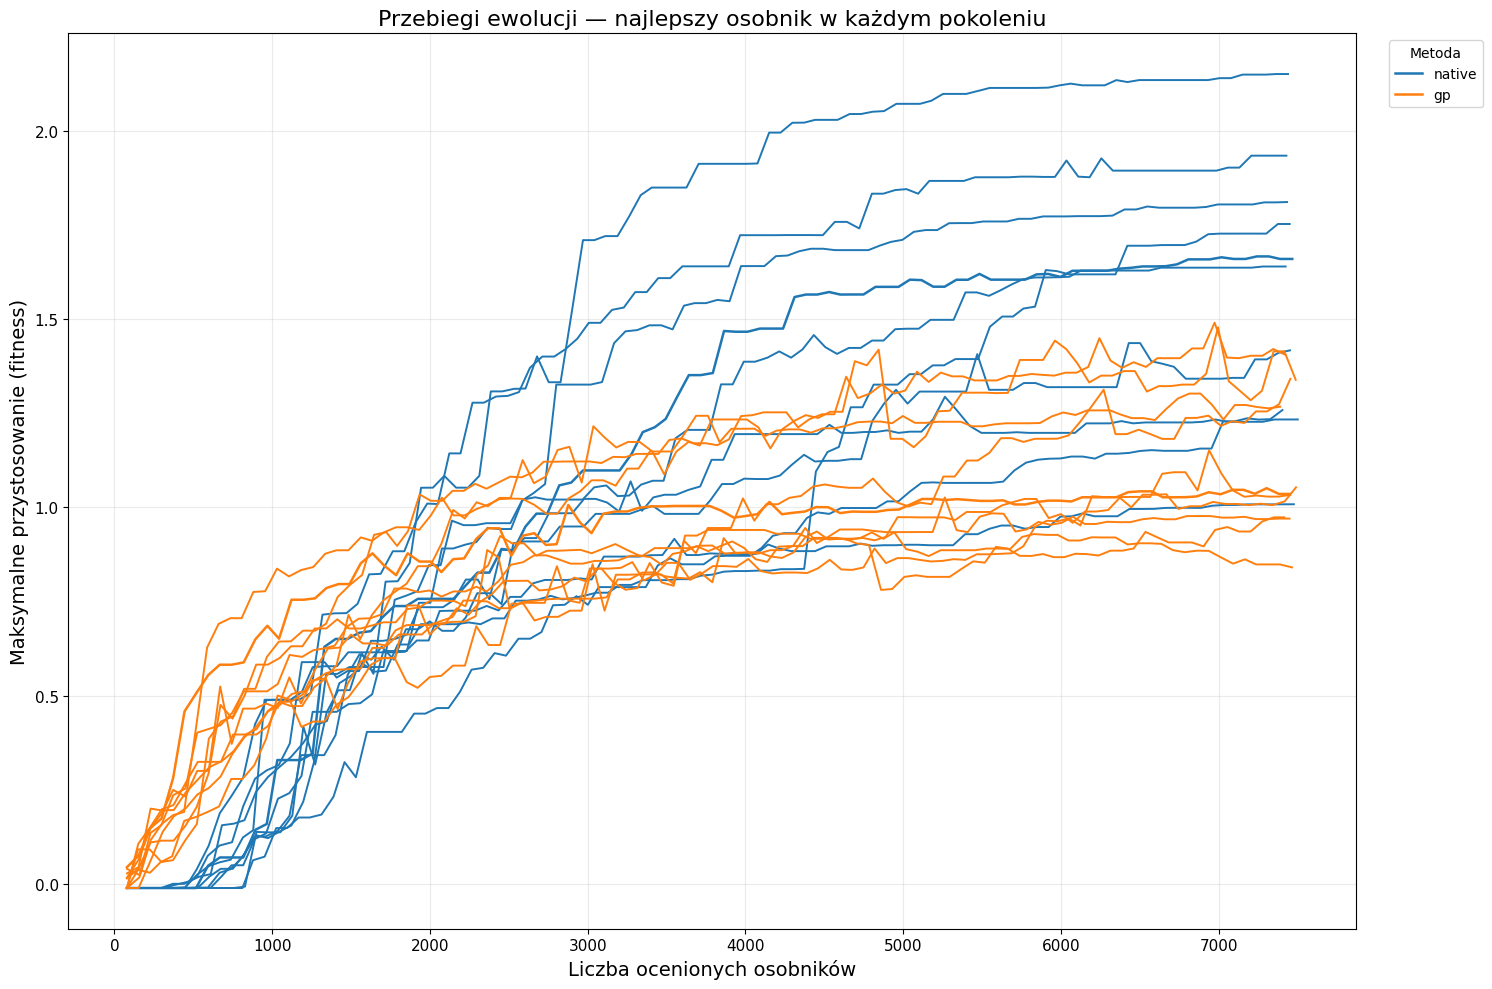

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

results_csv = "genotype_results.csv"
times_csv = "genotype_times.csv"

df = pd.read_csv(results_csv)
df_times = pd.read_csv(times_csv)

if "cumulative_nevals" not in df.columns:
    df["cumulative_nevals"] = df.groupby(["genotype_format", "iteration", "method"])["nevals"].cumsum()

plt.figure(figsize=(15, 10), dpi=100)


method_colors = {"native": "tab:blue", "gp": "tab:orange"}

methods = ["native", "gp"]
for method in methods:
    iters = sorted(df[df["method"] == method]["iteration"].unique())
    for iteration in iters:
        df_temp = df[
            (df["method"] == method) & 
            (df["iteration"] == iteration)
        ].sort_values("cumulative_nevals")
        if df_temp.empty:
            continue

        plt.plot(
            df_temp["cumulative_nevals"], 
            df_temp["max"],
            label=f"{method}" if iteration == iters[0] else None,
            color=method_colors[method],
            linewidth=1.8 if iteration == iters[0] else 1.4,
            alpha=1.0
        )

plt.title("Przebiegi ewolucji — najlepszy osobnik w każdym pokoleniu", fontsize=16)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()


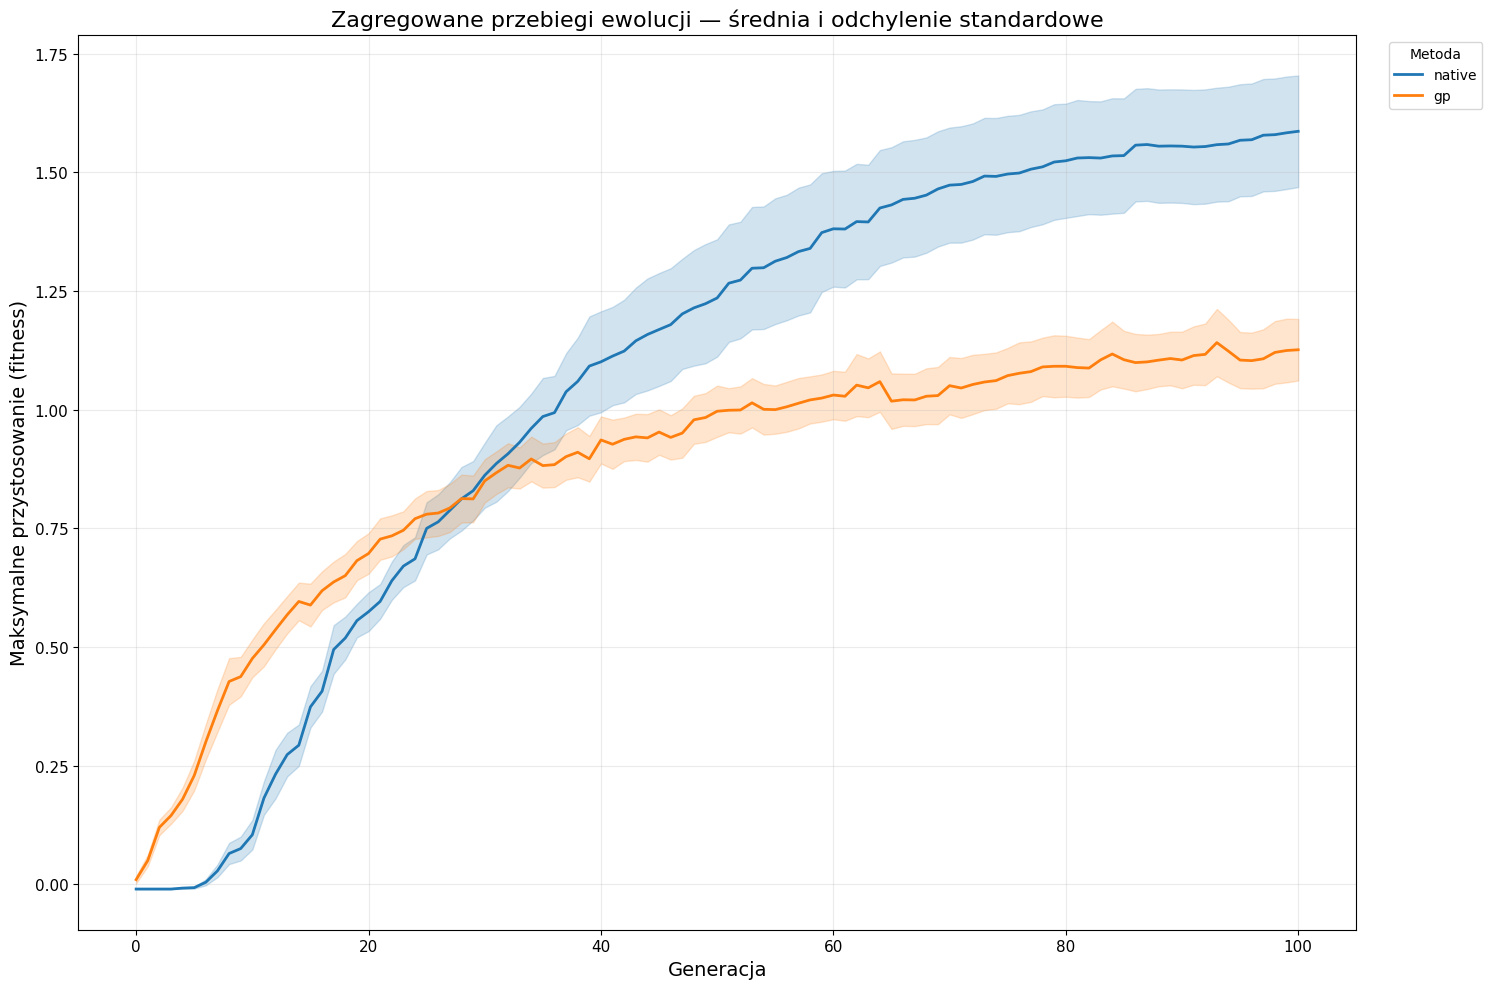

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

results_csv = "genotype_results.csv"
df = pd.read_csv(results_csv)
df_agg = df.groupby(["gen", "method"])["max"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(15, 10), dpi=100)

method_colors = {"native": "tab:blue", "gp": "tab:orange"}
SCALING_FACTOR = 3

methods = ["native", "gp"]
for method in methods:
    df_method = df_agg[df_agg["method"] == method]
    if df_method.empty:
        continue

    plt.plot(
        df_method["gen"], 
        df_method["mean"], 
        label=method, 
        color=method_colors[method], 
        linewidth=2
    )
    plt.fill_between(
        df_method["gen"],
        df_method["mean"] - df_method["std"] / SCALING_FACTOR,
        df_method["mean"] + df_method["std"] / SCALING_FACTOR,
        color=method_colors[method],
        alpha=0.2
    )

plt.title("Zagregowane przebiegi ewolucji — średnia i odchylenie standardowe", fontsize=16)
plt.xlabel("Generacja", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Metoda", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_zagregowane.png", dpi=200)
plt.show()

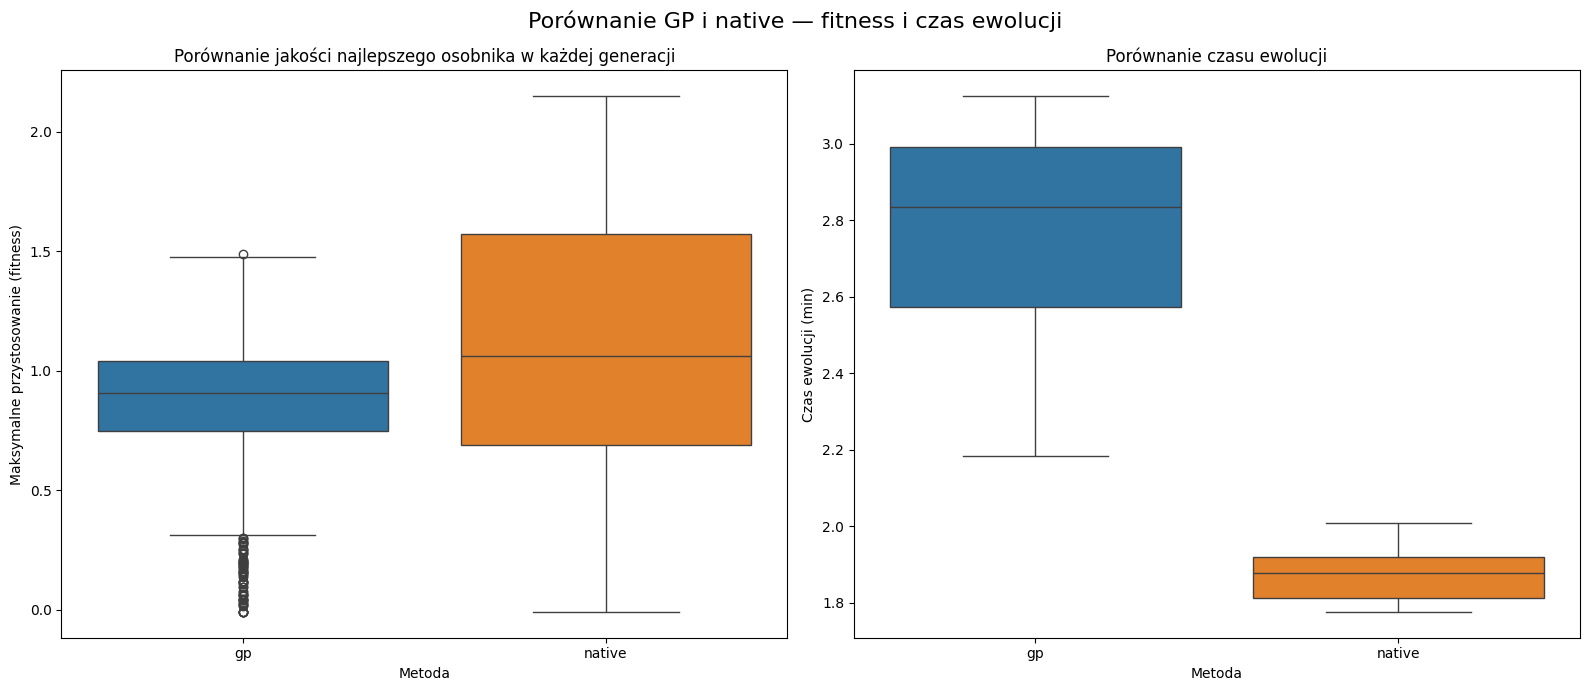

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_csv = "genotype_results.csv"
times_csv = "genotype_times.csv"

df = pd.read_csv(results_csv)
df_times = pd.read_csv(times_csv)

if "elapsed_time" in df_times.columns:
    df_times["elapsed_time"] /= 60

methods_sorted = sorted(df["method"].unique())
palette_colors = sns.color_palette("tab10")[:len(methods_sorted)]
palette = {m: color for m, color in zip(methods_sorted, palette_colors)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

sns.boxplot(
    ax=axes[0],
    x="method",
    y="max",
    hue="method",
    data=df,
    palette=palette,
    dodge=False,
    showfliers=True,
    legend=False
)
axes[0].set_xlabel("Metoda")
axes[0].set_ylabel("Maksymalne przystosowanie (fitness)")
axes[0].set_title("Porównanie jakości najlepszego osobnika w każdej generacji")

if "elapsed_time" in df_times.columns:
    sns.boxplot(
        ax=axes[1],
        x="method",
        y="elapsed_time",
        hue="method",
        data=df_times,
        palette=palette,
        dodge=False,
        showfliers=True,
        legend=False
    )
    axes[1].set_xlabel("Metoda")
    axes[1].set_ylabel("Czas ewolucji (min)")
    axes[1].set_title("Porównanie czasu ewolucji")
else:
    axes[1].set_visible(False)

plt.suptitle("Porównanie GP i native — fitness i czas ewolucji", fontsize=16)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_boxploty.png", dpi=200)
plt.show()


Wybranym problemem optymalizacyjnym był **„vertpos” bez sieci neuronowej**, z wykorzystaniem kodowania **f1**.

Po stronie GP zaimplementowano własny zestaw węzłów funkcyjnych i terminali, których zadaniem było konstruowanie poprawnych składniowo genotypów Framsticks w reprezentacji f1. Drzewo GP nie reprezentowało bezpośrednio gotowego genotypu, lecz strukturę pośrednią, która po ewaluacji była deterministycznie przekształcana do ciągu znaków.

Podstawowym elementem budulcowym był „stick”, reprezentowany przez symbol X. Jego generowanie zostało zrealizowane przez funkcję `frams_stick`, która zawsze wprowadza do genotypu poprawną strukturę bazową, a opcjonalnie dołącza dalszą część drzewa. Zapewnia to, że nawet po mutacjach i krzyżowaniu większość osobników zawiera sensowny rdzeń morfologii.

```python
def frams_stick(tail):
    res = "X"
    if tail:
        res += tail
    return res
```

Dodawanie nawiasów, które w kodowaniu f1 odpowiadają za tworzenie gałęzi, zostało ograniczone przez funkcję `frams_paren`. Nawiasy są generowane wyłącznie wtedy, gdy wewnętrzna sekwencja faktycznie zawiera symbol X. Jest to celowe zabezpieczenie przed tworzeniem pustych lub bezsensownych konstrukcji, które w praktyce nie niosą informacji morfologicznej i pogarszają jakość populacji.

```python
def frams_paren(tail):
    if not tail:
        return ""
    if "X" not in tail:
        return ""
    return "(" + tail + ")"
```

Rozgałęzienia w genotypie realizowane są przez operator przecinka. Funkcja `frams_branch` buduje konstrukcję typu `head`,`tail`, przy czym oba argumenty są opcjonalne. Takie rozwiązanie pozwala GP elastycznie tworzyć struktury liniowe oraz rozgałęzione, a jednocześnie zachowuje zgodność z gramatyką f1.

```python
def frams_branch(head, tail):
    res = ""
    if head:
        res += head
    if tail:
        res += "," + tail
    return res
```

Modyfikatory (np. *R, r, Q, C, L, W, F*) zostały zaimplementowane jako funkcje wyższego rzędu, generowane przez `frams_modif`. Każdy modyfikator może być zastosowany wyłącznie do struktury typu **Tree**, co odzwierciedla ograniczenia kodowania **f1**, gdzie modyfikatory nie mogą występować samodzielnie ani działać na pustych sekwencjach. Jeśli przekazana struktura jest pusta, modyfikator nie jest stosowany, co ogranicza powstawanie niepoprawnych genotypów.

```python
def frams_modif(mod):
    def apply(tail):
        if not tail:
            return ""
        return mod + tail
    return apply
```

Uzyskane wyniki pokazują wyraźną różnicę w charakterystyce działania obu podejść. Programowanie genetyczne bardzo szybko poprawiało jakość rozwiązań w początkowych generacjach — w pierwszej fazie ewolucji maksymalne wartości fitness rosły szybciej niż w przypadku ewolucji natywnej. Po pewnym czasie następowało jednak wyraźne wysycenie i stagnacja, a dalsze poprawy były niewielkie. Ewolucja działająca w natywnej przestrzeni Framsticks rozwijała się wolniej, lecz stabilniej i w dłuższej perspektywie osiągała znacznie lepsze wyniki końcowe.

Najlepszy osobnik uzyskany metodą GP osiągnął wartość fitness równą **1.49**. Przykładowe drzewo GP było bardzo rozbudowane i złożone:
```
mod_C(mod_C(mod_r(mod_L(mod_L(frams_paren(frams_branch(mod_r(mod_W(mod_C('X'))), frams_branch(mod_W(frams_stick(mod_F(mod_F('X')))), frams_branch(mod_r(mod_r(mod_q(mod_r(frams_paren(None))))), frams_branch(mod_r(frams_stick(mod_W(frams_paren(frams_branch(mod_F(mod_F(mod_f(frams_stick(mod_C(mod_L(mod_q(mod_f(mod_c(frams_stick(frams_paren(frams_branch(frams_paren(frams_branch(mod_Q(mod_W(mod_C(mod_R(frams_stick('X'))))), '')), frams_branch(mod_F(mod_q('X')), None))))))))))))), frams_branch(mod_Q(mod_R(mod_R(mod_f(mod_C(mod_f(mod_L(mod_w(mod_f(frams_paren(None)))))))))), frams_branch(mod_Q(mod_f(mod_L(mod_r('X')))), frams_branch('X', None)))))))), frams_branch(mod_C(frams_paren(None)), frams_branch(mod_Q(mod_r(frams_stick('X'))), None))))))))))))
```
a po konwersji do reprezentacji Framsticks dawało genotyp:
```CCrLL(rWCX,WXFFX,,rXW(FFfXCLqfcX((QWCRXX),FqX),,QfLrX,X),,QrXX)```

<img src="best_gp.png" width="1200">

Dla porównania najlepszy osobnik uzyskany w natywnej przestrzeni Framsticks miał dużo prostszy genotyp:

```qLLL(rLLXLLLMm(LLLLXfXrrXQm(LLfX, ), LLFFmFqqX), RLX, )```

<img src="best_native.png" width="1200">

i osiągnął fitness równy **2.15**, co wyraźnie przewyższa wynik uzyskany przez GP.

Na podstawie przeprowadzonych eksperymentów można stwierdzić, że zastosowana transformacja przestrzeni drzew GP do przestrzeni genotypów Framsticks nie odtwarza w pełni struktury tej przestrzeni. GP ma tendencję do generowania bardzo długich i skomplikowanych osobników, co przy obecnych parametrach prowadzi do „puchnięcia” drzew i utrudnia dalszą optymalizację. Natywne operatory Framsticks wydają się lepiej dopasowane do specyfiki problemu „vertpos” i pozwalają na skuteczniejsze eksplorowanie przestrzeni rozwiązań w dłuższym horyzoncie ewolucji. Potencjalną poprawę wyników GP mogłoby przynieść wprowadzenie silniejszych ograniczeń strukturalnych, innych operatorów genetycznych lub bardziej zaawansowanych strategii sterowania ewolucją.